**Group information**

| Family name | First name | Email address |
| ----------- | ---------- | ------------- |
|             |            |               |
|             |            |               |
|             |            |               |

# Semantic segmentation - Homework

This tutorial explores how to automatically extract building footprints from aerial images. The objective is to perform semantic segmentation, or approximate the function that maps input images to class probabilities for each pixel. For this assignment, we use the U-Net convolutional network architecture [(Ronneberger et al. 2015)](https://link.springer.com/chapter/10.1007/978-3-319-24574-4_28). The GPU implementation of PyTorch is recommended.

The image dataset consists of 3347 colour images, each with dimensions $3 \times 256 \times 256$, sourced from [Minh (2013)](http://www.cs.toronto.edu/~vmnih/data/). Each image corresponds to a 300-square-metre area within the state of Massachusetts. The labels are building footprint vectors derived from [OpenStreetMap](https://www.openstreetmap.org/relation/61315), which have been rasterised into binary masks matching the spatial extent and resolution of the input images. For efficient storage, images and labels are saved in the JPEG format.

![U-Net model](https://www.dropbox.com/scl/fi/wgvqiix6scbm1c983ephk/segmentation_model.jpg?rlkey=71blfq7cm1yzw26puu4l0ybhs&dl=1)

In [ ]:
# Packages
import os
import shutil
import torch
import tqdm

import matplotlib.pyplot as plt
from torch import nn, optim, utils
from torchmetrics import classification
from torchvision import io, ops
from urllib import request
import os
from torch.utils.data import TensorDataset, DataLoader, random_split
import copy
from torchvision.ops import sigmoid_focal_loss
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Device
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
device = torch.device(device)

# Utilities
classes = {0:'non-building', 255:'building'}

In [57]:
# Utilities
def download_data():
    if os.getcwd().endswith('/data'):
        print('Data folder already exists')
    else:
        request.urlretrieve('https://www.dropbox.com/scl/fo/90urs56ftly5r28jk18i4/AB2AIFdymQmeEqJZ8Og0V4Q?rlkey=nkb2w0fmfuym7sbgqpqnvm9cd&dl=1', 'data.zip')
        shutil.unpack_archive('data.zip', 'data')
        os.remove('data.zip')
        os.chdir('data')

def display_image(image:torch.Tensor, title:str='', cmap:str='gray', figsize=(5, 5)) -> None:
    image   = torch.einsum('dhw -> hwd', image)
    fig, ax = plt.subplots(1, figsize=figsize)
    ax.imshow(image, cmap=cmap)
    ax.set_title(title, fontsize=15)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
    plt.close()

1. Load the images and labels as `torch.Tensor` of dimensions $n \times d \times h \times w$. Normalise the images and labels between 0 and 1 and set the data type as `torch.float32`.

<small>Note: In the label images, pixel values of 0 indicate non-building areas, while 255 indicate buildings. Due to JPEG's lossy compression, some values may slightly differ from 0 or 255. You can round the pixel values to restore binary labels.</small>

In [ ]:
# download_data()

In [59]:
def load_dataset(image_dir_path: str, label_dir_path: str) -> tuple[torch.Tensor, torch.Tensor]:
    
    image_files = sorted([f for f in os.listdir(image_dir_path)])
    label_files = sorted([f for f in os.listdir(label_dir_path)])
    
    # Check for empty lists or mismatches
    if len(image_files) == 0:
        raise ValueError(f"No images found in '{image_dir_path}'. Check your paths.")
    if len(image_files) != len(label_files):
        raise ValueError(f"Mismatch: Found {len(image_files)} images and {len(label_files)} labels.")

    image_list = []
    label_list = []

    for img_file, lbl_file in zip(image_files, label_files):
        img_path = os.path.join(image_dir_path, img_file)
        lbl_path = os.path.join(label_dir_path, lbl_file)
        
        img_tensor = io.read_image(img_path, mode=io.ImageReadMode.RGB) # Forced to 3 channels
        lbl_tensor = io.read_image(lbl_path, mode=io.ImageReadMode.GRAY) # Forced to 1 channel
        
        img_tensor = img_tensor.to(torch.float32) / 255.0
        lbl_tensor = lbl_tensor.to(torch.float32) / 255.0
        
        lbl_tensor = torch.round(lbl_tensor)
        
        image_list.append(img_tensor)
        label_list.append(lbl_tensor)
        
    # Stack lists of (D x H x W) tensors into a single (N x D x H x W) tensor
    images = torch.stack(image_list)
    labels = torch.stack(label_list)
    
    return images, labels

images, labels = load_dataset('../data/images', '../data/labels')

2. Check the array dimensions and display several image–label pairs to ensure that they are correctly aligned.

Image Tensor shape: torch.Size([3347, 3, 256, 256])
Label Tensor shape: torch.Size([3347, 1, 256, 256])


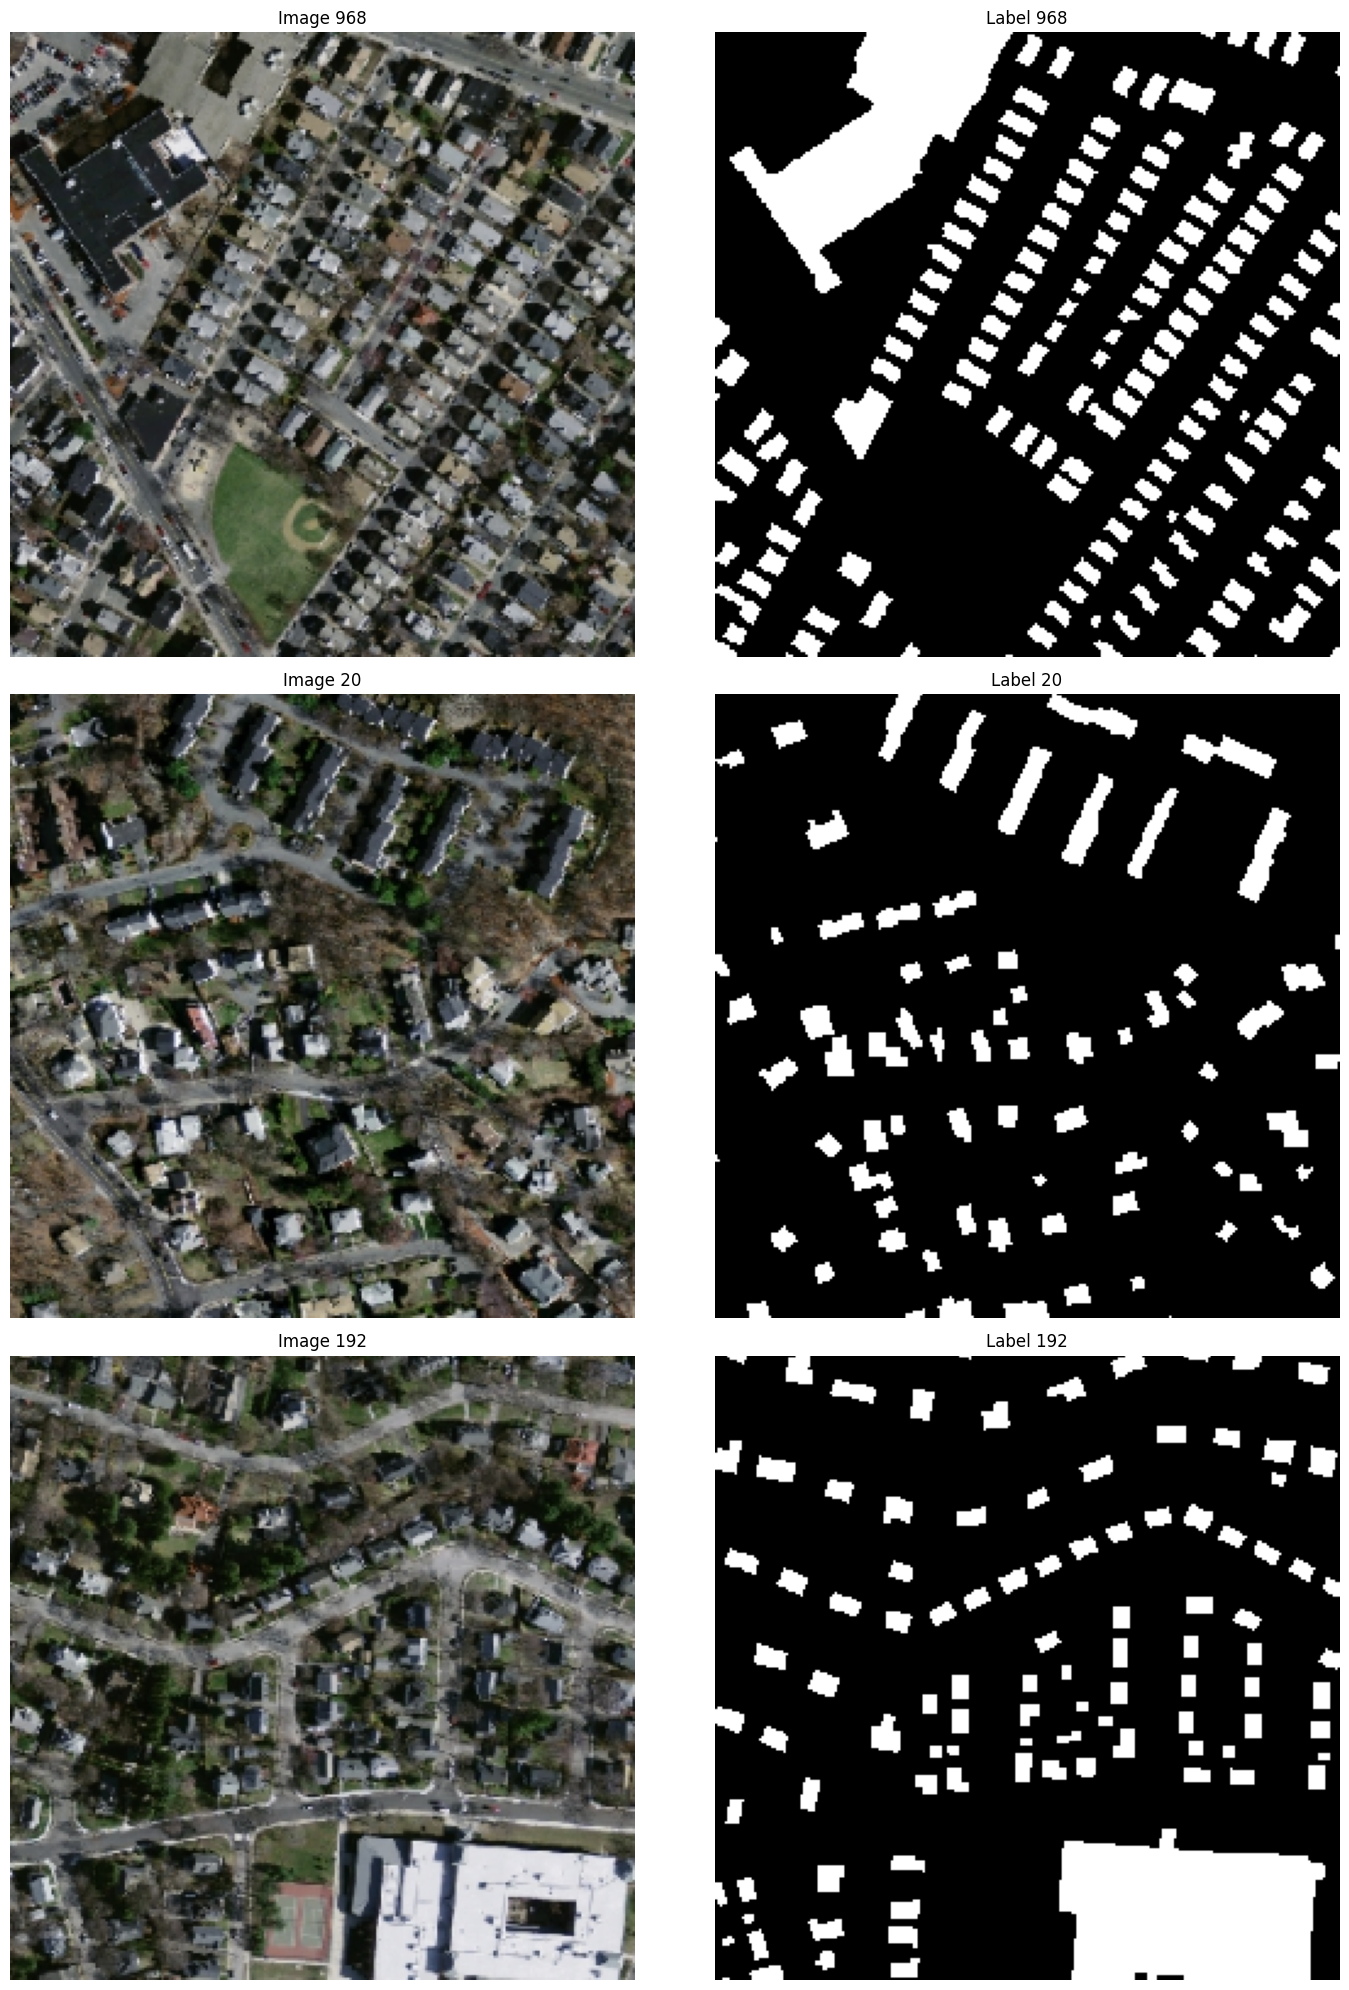

In [ ]:
print(f"Image Tensor shape: {images.shape}")
print(f"Label Tensor shape: {labels.shape}")

indices = [968,20,192] # add idx 2
idx = [0,1,2]
sample_images = images[indices]
sample_labels = labels[indices]

img_to_plot = [image.permute(1, 2, 0).numpy() for image in sample_images]
lbl_to_plot = [label.squeeze().numpy() for label in sample_labels]

fig, axes = plt.subplots(3, 2, figsize=(15, 20))

for idx, img, lab in zip(idx, img_to_plot, lbl_to_plot):
    # Plot the original image
    axes[idx][0].imshow(img)
    axes[idx][0].set_title(f"Image {indices[idx]}")
    axes[idx][0].axis('off') # Hides the axes ticks

    # Plot labels
    axes[idx][1].imshow(lab, cmap='gray')
    axes[idx][1].set_title(f"Label {indices[idx]}")
    axes[idx][1].axis('off')

plt.tight_layout()
plt.show()

3. Format the data as a `TensorDataset` and partition the observations into training (75%) and test (25%) samples. For each sample, create a `DataLoader` with a batch size suitable for your hardware (e.g. between 32 and 256).

<small>Note: Optionally, you can also include a validation sample by splitting the dataset into 70% training, 15% validation, and 15% test.</small>

In [ ]:
dataset = TensorDataset(images, labels)

total_samples = len(dataset)
train_size = int(0.70 * total_samples)
val_size = int(0.15 * total_samples)
test_size = total_samples - train_size - val_size

generator = torch.Generator().manual_seed(895)
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

batch_size = 64 

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False
)

4. Using PyTorch, define a simplified U-Net model with the number of filters indicated in the figure above (i.e. 8, 16, 32, 64, 128, ...). Choose the appropriate activation functions for the hidden layers and the output layer.

<small>Note: Optionally, you can include batch normalisation and spatial dropout layers to improve the model’s optimisation and generalisation, respectively.</small>

In [70]:
class DoubleConv(nn.Module):
    """
    A helper module consisting of (Conv2d -> BatchNorm2d -> ReLU) * 2 -> Dropout2d.
    Using padding=1 ensures the spatial dimensions remain the same after convolutions.
    """
    def __init__(self, in_channels, out_channels, dropout_rate=0.1):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            
            # Spatial dropout drops entire 2D feature maps to promote generalization
            nn.Dropout2d(p=dropout_rate)
        )

    def forward(self, x):
        return self.double_conv(x)


class UNetSimplified(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        """
        Simplified U-Net with filter sizes: 8, 16, 32, 64, 128.
        in_channels: 3 for RGB images, 1 for Grayscale.
        out_channels: 1 for binary classification (building vs. non-building).
        """
        super().__init__()
        
        # --- Encoder (Downsampling Path) ---
        self.enc1 = DoubleConv(in_channels, 8)
        self.enc2 = DoubleConv(8, 16)
        self.enc3 = DoubleConv(16, 32)
        self.enc4 = DoubleConv(32, 64)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # --- Bottleneck ---
        # Dropout rate is slightly higher in the bottleneck
        self.bottleneck = DoubleConv(64, 128, dropout_rate=0.2)
        
        # --- Decoder (Upsampling Path) ---
        # ConvTranspose2d doubles the spatial dimensions and halves the channels
        self.upconv4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        # Input channels to dec4 is 64 (from upconv) + 64 (from skip connection) = 128
        self.dec4 = DoubleConv(128, 64)
        
        self.upconv3 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(64, 32)
        
        self.upconv2 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(32, 16)
        
        self.upconv1 = nn.ConvTranspose2d(16, 8, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(16, 8)
        
        # --- Output Layer ---
        # 1x1 Convolution to map the 8-channel output to the desired number of classes (1)
        self.final_conv = nn.Conv2d(8, out_channels, kernel_size=1)
        
    def forward(self, x):
        # Encoder Forward Pass (Saving outputs for skip connections)
        skip1 = self.enc1(x)
        x = self.pool(skip1)
        
        skip2 = self.enc2(x)
        x = self.pool(skip2)
        
        skip3 = self.enc3(x)
        x = self.pool(skip3)
        
        skip4 = self.enc4(x)
        x = self.pool(skip4)
        
        # Bottleneck Forward Pass
        x = self.bottleneck(x)
        
        # Decoder Forward Pass (Concatenating skip connections)
        x = self.upconv4(x)
        x = torch.cat([x, skip4], dim=1) # Concatenate along the channel dimension (dim=1)
        x = self.dec4(x)
        
        x = self.upconv3(x)
        x = torch.cat([x, skip3], dim=1)
        x = self.dec3(x)
        
        x = self.upconv2(x)
        x = torch.cat([x, skip2], dim=1)
        x = self.dec2(x)
        
        x = self.upconv1(x)
        x = torch.cat([x, skip1], dim=1)
        x = self.dec1(x)
        
        # Output Forward Pass
        x = self.final_conv(x)
        
        return x

5. Initialise the model and print its architecture. Select an appropriate optimisation algorithm and loss function.

<small>Note: To address class imbalance — since building pixels represent only a small fraction of the total — you can weight the loss function or use loss functions specifically designed for imbalance, such as `torchvision.ops.sigmoid_focal_loss`.</small>


In [71]:
model = UNetSimplified(in_channels=3, out_channels=1)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)

print(model)

# AdamW is an excellent default for U-Net architectures. 
# It improves upon standard Adam by decoupling weight decay, leading to better generalization.
learning_rate = 1e-3
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)

def calculate_loss(predictions: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    """
    Computes the Focal Loss to handle the heavy class imbalance of building pixels.
    
    Args:
        predictions: The raw logits output by the model (NO sigmoid applied).
        targets: The ground truth binary masks (0.0 or 1.0).
    """
    # alpha: Weights the importance of the positive class (buildings).
    # gamma: Down-weights the loss contributed by easy-to-classify background pixels,
    #        forcing the model to focus on hard-to-classify edges and small buildings.
    loss = sigmoid_focal_loss(
        inputs=predictions, 
        targets=targets, 
        alpha=0.25,   
        gamma=2.0,    
        reduction='mean'
    )
    return loss

UNetSimplified(
  (enc1): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): Dropout2d(p=0.1, inplace=False)
    )
  )
  (enc2): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, trac

6. Write the PyTorch training routine and estimate the model parameters using the training sample.

Note: If you use a validation sample, implement a validation routine and apply early stopping to prevent overfitting.

In [ ]:
def train_model_with_early_stopping(
    model, train_loader, val_loader, optimizer, device, 
    num_epochs=50, patience=5
):
    """
    Trains the U-Net model with validation and early stopping.
    """
    print(f"Starting training on device: {device}")
    model = model.to(device)
    
    # --- Early Stopping Setup ---
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_wts = copy.deepcopy(model.state_dict())
    
    for epoch in range(num_epochs):
        model.train() 
        running_train_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            predictions = model(images)
            loss = calculate_loss(predictions, labels)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * images.size(0)
            
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        
        model.eval() 
        running_val_loss = 0.0
        
        # Disable gradient calculation for validation to save memory and speed up computation
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                
                predictions = model(images)
                loss = calculate_loss(predictions, labels)
                
                running_val_loss += loss.item() * images.size(0)
                
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        
        print(f"Epoch [{epoch + 1:02d}/{num_epochs:02d}] | "
              f"Train Loss: {epoch_train_loss:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}")

        # Early Stopping        
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_no_improve = 0
            # Save the best weights found so far
            best_model_wts = copy.deepcopy(model.state_dict())
            print("  --> Validation loss improved! Saving model weights.")
        else:
            epochs_no_improve += 1
            print(f"  --> No improvement for {epochs_no_improve} epoch(s).")
            
            # If we haven't improved for 'patience' epochs, stop training
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping triggered after {epoch + 1} epochs!")
                break

    print("\nTraining complete. Loading best model weights.")
    model.load_state_dict(best_model_wts)
    
    return model

trained_model = train_model_with_early_stopping(model, train_loader, val_loader, optimizer, device)

Starting training on device: mps
Epoch [01/50] | Train Loss: 0.0583 | Val Loss: 0.0403
  --> Validation loss improved! Saving model weights.
Epoch [02/50] | Train Loss: 0.0384 | Val Loss: 0.0326
  --> Validation loss improved! Saving model weights.
Epoch [03/50] | Train Loss: 0.0325 | Val Loss: 0.0273
  --> Validation loss improved! Saving model weights.
Epoch [04/50] | Train Loss: 0.0293 | Val Loss: 0.0253
  --> Validation loss improved! Saving model weights.
Epoch [05/50] | Train Loss: 0.0273 | Val Loss: 0.0232
  --> Validation loss improved! Saving model weights.
Epoch [06/50] | Train Loss: 0.0252 | Val Loss: 0.0220
  --> Validation loss improved! Saving model weights.
Epoch [07/50] | Train Loss: 0.0240 | Val Loss: 0.0219
  --> Validation loss improved! Saving model weights.
Epoch [08/50] | Train Loss: 0.0230 | Val Loss: 0.0200
  --> Validation loss improved! Saving model weights.
Epoch [09/50] | Train Loss: 0.0223 | Val Loss: 0.0188
  --> Validation loss improved! Saving model weig

7. Compute the predicted probabilities for the test images.

In [ ]:
model.eval()
    
all_probabilities = []
all_ground_truths = []
    
with torch.no_grad():
    for images, labels in test_loader:
        # Move inputs to the correct device
        images = images.to(device)   
        logits = model(images)
            
        probabilities = torch.sigmoid(logits)
            
        all_probabilities.append(probabilities.cpu())
        all_ground_truths.append(labels.cpu())
            
test_probabilities = torch.cat(all_probabilities, dim=0)
test_labels = torch.cat(all_ground_truths, dim=0)
    
print("Inference complete!")

Inference complete!


8. Assess the model's generalisation performance by computing the confusion matrix, along with precision and recall metrics on the test sample. Comment on the results.

Evaluating with probability threshold: 0.5

--- Metrics ---
Precision: 0.8878 (88.78%)
Recall:    0.4412 (44.12%)


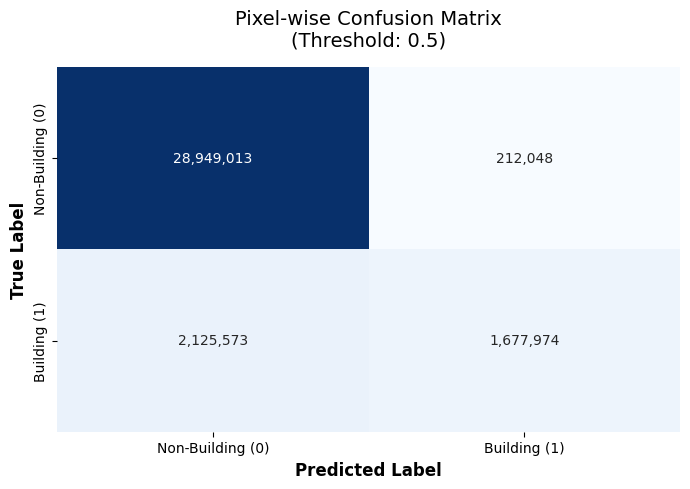

In [ ]:
def evaluate_performance(test_probs: torch.Tensor, test_labels: torch.Tensor, threshold: float = 0.5):
    """
    Computes and plots the confusion matrix, precision, and recall for binary segmentation.
    """
    print(f"Evaluating with probability threshold: {threshold}")
    
    # Convert soft probabilities into hard binary predictions (0 or 1)
    predictions = (test_probs >= threshold).int()
    labels = test_labels.int()
    
    # Flatten the tensors from (N, 1, H, W) to a single 1D array
    preds_flat = predictions.view(-1)
    labels_flat = labels.view(-1)
    
    # 3. Compute Confusion Matrix components
    TP = ((preds_flat == 1) & (labels_flat == 1)).sum().item()
    FP = ((preds_flat == 1) & (labels_flat == 0)).sum().item()
    TN = ((preds_flat == 0) & (labels_flat == 0)).sum().item()
    FN = ((preds_flat == 0) & (labels_flat == 1)).sum().item()
    
    # 4. Compute Metrics
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    
    print("\n== Metrics ==")
    print(f"Precision: {precision:.4f} ({precision * 100:.2f}%)")
    print(f"Recall:    {recall:.4f} ({recall * 100:.2f}%)")
        
    cm = np.array([[TN, FP],
                   [FN, TP]])
    
    plt.figure(figsize=(7, 5))
    
    # Create a heatmap
    sns.heatmap(
        cm, 
        annot=True, 
        fmt=',d', 
        cmap='Blues', 
        cbar=False,
        xticklabels=['Non-Building (0)', 'Building (1)'],
        yticklabels=['Non-Building (0)', 'Building (1)']
    )
    
    plt.title(f'Pixel-wise Confusion Matrix\n(Threshold: {threshold})', pad=15, fontsize=14)
    plt.xlabel('Predicted Label', weight='bold', fontsize=12)
    plt.ylabel('True Label', weight='bold', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    return TP, FP, TN, FN, precision, recall

tp, fp, tn, fn, precision, recall = evaluate_performance(test_probabilities, test_labels)

9. Implement a function to visualise true positives, true negatives, false positives, and false negatives as overlays on the input image.

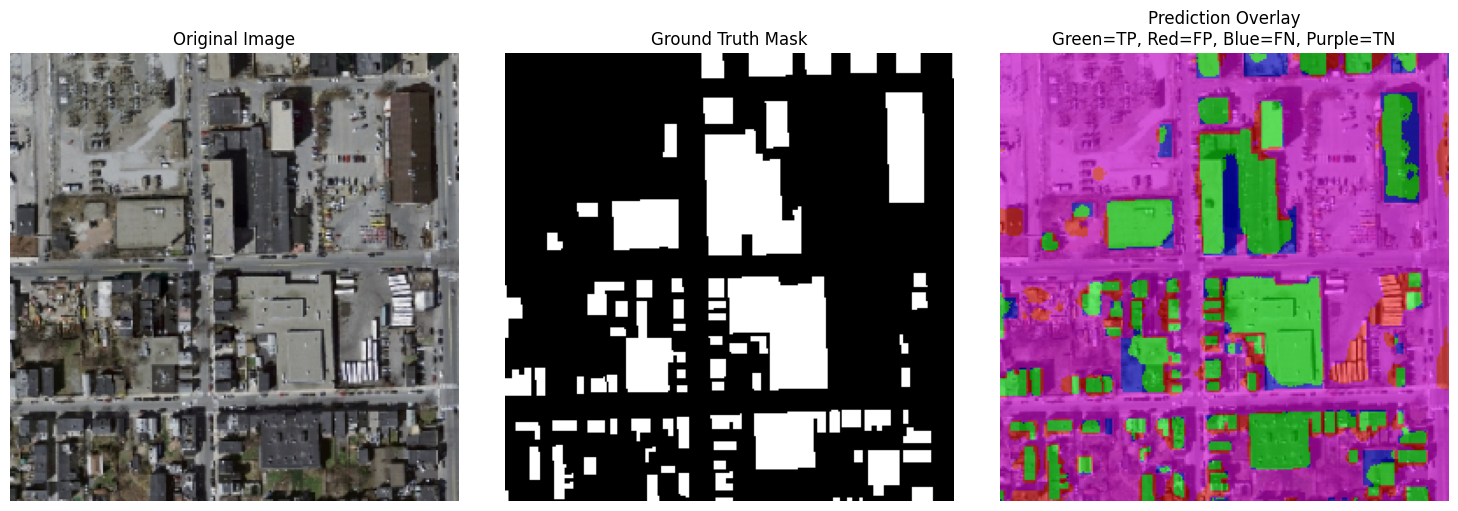

In [ ]:
def visualize_prediction_overlay(
    image_tensor: torch.Tensor, 
    label_tensor: torch.Tensor, 
    prob_tensor: torch.Tensor, 
    threshold: float = 0.5,
    alpha: float = 0.5
):
    """
    Overlays TP (Green), FP (Red), and FN (Blue) onto the original image.
    Expects single image tensors of shape (C, H, W).
    """
    # Convert PyTorch tensors to Numpy arrays and reshape for Matplotlib (H, W, C)
    # Image: (3, H, W) -> (H, W, 3)
    img = image_tensor.cpu().permute(1, 2, 0).numpy()
    
    # Label and Prob: (1, H, W) -> (H, W)
    lbl = label_tensor.cpu().squeeze().numpy()
    prob = prob_tensor.cpu().squeeze().numpy()
    
    # Get binary predictions based on the threshold
    pred = (prob >= threshold).astype(int)
    lbl = lbl.astype(int)
    
    # Calculate masks for TP, FP, and FN
    TP = (pred == 1) & (lbl == 1)
    FP = (pred == 1) & (lbl == 0)
    FN = (pred == 0) & (lbl == 1)
    TN = (pred == 0) & (lbl == 0)
    
    overlay = np.zeros_like(img)
    
    # Apply colors to the overlay
    overlay[TP] = [0.0, 1.0, 0.0]  # Green
    overlay[FP] = [1.0, 0.0, 0.0]  # Red
    overlay[FN] = [0.0, 0.0, 1.0]  # Blue
    overlay[TN] = [1.0, 0.0, 1.0]  # Purple
    
    alpha_mask = np.zeros(img.shape[:2])
    alpha_mask[TP | FP | FN | TN] = alpha
    
    # Expand alpha mask to 3 channels so it can be broadcasted with the RGB images
    alpha_mask = np.expand_dims(alpha_mask, axis=-1)
    
    # Blend the original image and the overlay
    blended_img = (img * (1.0 - alpha_mask)) + (overlay * alpha_mask)
    
    # Ensure values are strictly clipped between 0 and 1 for Matplotlib
    blended_img = np.clip(blended_img, 0.0, 1.0)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img)
    axes[0].set_title("Original Image")
    axes[0].axis('off')
    
    axes[1].imshow(lbl, cmap='gray')
    axes[1].set_title("Ground Truth Mask")
    axes[1].axis('off')
    
    axes[2].imshow(blended_img)
    axes[2].set_title(f"Prediction Overlay\nGreen=TP, Red=FP, Blue=FN, Purple=TN")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

index = 25 # add idx 1, 2
sample_image, _ = test_dataset[index]
sample_label = test_labels[index]
sample_prob = test_probabilities[index]

visualize_prediction_overlay(
    image_tensor=sample_image, 
    label_tensor=sample_label, 
    prob_tensor=sample_prob, 
    threshold=0.34, 
    alpha=0.5
)

10. Assuming that we give equal importance to reducing false positives and false negatives, use a decision probability threshold that strikes the best balance between these two quantities.


== Optimal Threshold Found: 0.344 ==
Max F1-Score: 0.7390
Precision at this threshold: 0.7066
Recall at this threshold:    0.7744
False Positives: 1,222,707
False Negatives: 858,179


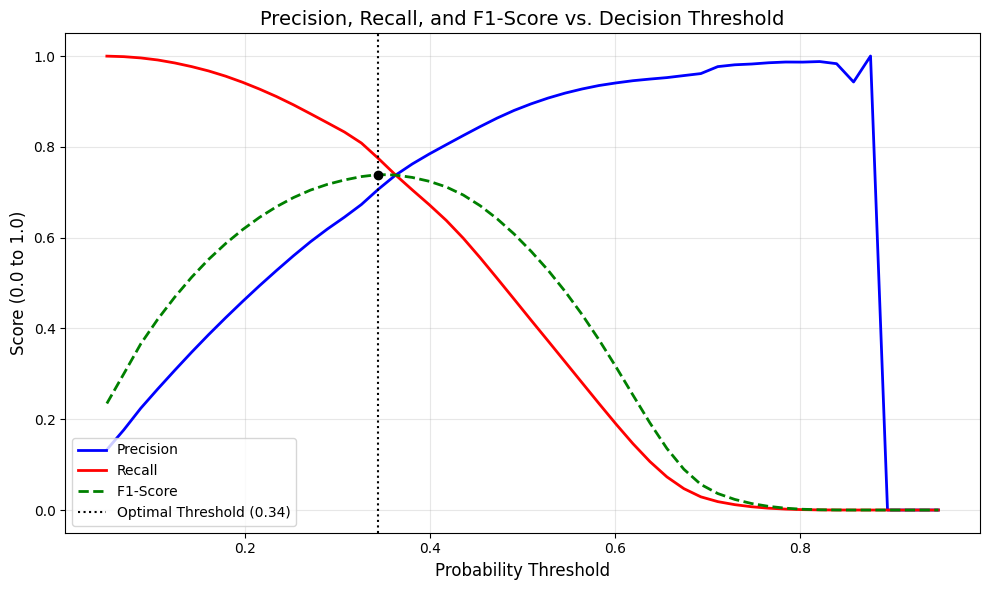

In [80]:
def find_optimal_threshold(test_probs: torch.Tensor, test_labels: torch.Tensor, num_steps: int = 50):
    """
    Iterates through possible thresholds to find the one that maximizes the F1-Score,
    striking the best balance between False Positives and False Negatives.
    """
    # Flatten tensors once outside the loop to save time and memory
    probs_flat = test_probs.view(-1)
    labels_flat = test_labels.view(-1).int()
    
    # Test thresholds from 0.05 to 0.95
    thresholds = np.linspace(0.05, 0.95, num_steps)
    
    precisions = []
    recalls = []
    f1_scores = []
    
    best_f1 = 0.0
    best_thresh = 0.5
    best_metrics = {}
    
    for t in thresholds:
        preds = (probs_flat >= t).int()
        
        TP = ((preds == 1) & (labels_flat == 1)).sum().item()
        FP = ((preds == 1) & (labels_flat == 0)).sum().item()
        FN = ((preds == 0) & (labels_flat == 1)).sum().item()
        
        # Calculate Metrics
        P = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        R = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        F1 = 2 * (P * R) / (P + R) if (P + R) > 0 else 0.0
        
        precisions.append(P)
        recalls.append(R)
        f1_scores.append(F1)
        
        # Track the best threshold
        if F1 > best_f1:
            best_f1 = F1
            best_thresh = t
            best_metrics = {'P': P, 'R': R, 'TP': TP, 'FP': FP, 'FN': FN}
            
    print(f"\n== Optimal Threshold Found: {best_thresh:.3f} ==")
    print(f"Max F1-Score: {best_f1:.4f}")
    print(f"Precision at this threshold: {best_metrics['P']:.4f}")
    print(f"Recall at this threshold:    {best_metrics['R']:.4f}")
    print(f"False Positives: {best_metrics['FP']:,}")
    print(f"False Negatives: {best_metrics['FN']:,}")
    
    # Plot
    plt.figure(figsize=(10, 6))
    
    plt.plot(thresholds, precisions, label='Precision', color='blue', linewidth=2)
    plt.plot(thresholds, recalls, label='Recall', color='red', linewidth=2)
    plt.plot(thresholds, f1_scores, label='F1-Score ', color='green', linewidth=2, linestyle='--')
    
    # Highlight the optimal point
    plt.axvline(x=best_thresh, color='black', linestyle=':', label=f'Optimal Threshold ({best_thresh:.2f})')
    plt.scatter([best_thresh], [best_f1], color='black', zorder=5)
    
    plt.title('Precision, Recall, and F1-Score vs. Decision Threshold', fontsize=14)
    plt.xlabel('Probability Threshold', fontsize=12)
    plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
    plt.legend(loc='lower left', fontsize=10)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return best_thresh

optimal_thresh = find_optimal_threshold(test_probabilities, test_labels)

Add confusion matrix and sample images (the same that previously on test)